<a href="https://colab.research.google.com/github/manoharreddyvoladri/Quantum_Classification/blob/main/i_like_weed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

manoharreddyvoladri_project_2_path = kagglehub.dataset_download('manoharreddyvoladri/project-2')

print('Data source import complete.')


In [ ]:
import os
import json
import torch
import torch.utils.data as data
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision.transforms as transforms
from PIL import Image, ImageDraw
import numpy as np
from tqdm import tqdm
import time

# Dataset class
class MaizeWeedDataset(data.Dataset):
    def __init__(self, root_dir, transform=None, use_json=True):
        self.root_dir = root_dir
        self.transform = transform
        self.use_json = use_json
        self.image_files = [f for f in os.listdir(root_dir) if f.endswith('.jpg')]

    def __len__(self):
        return len(self.image_files)

    def load_annotations_from_json(self, json_path, img_width, img_height):
        with open(json_path, 'r') as f:
            annotations = json.load(f)

        boxes = []
        labels = []

        for anno in annotations[0]['annotations']:
            # Get coordinates
            x = anno['coordinates']['x']
            y = anno['coordinates']['y']
            width = anno['coordinates']['width']
            height = anno['coordinates']['height']

            # Convert to [x_min, y_min, x_max, y_max] format
            x_min = max(0, x - width / 2)
            y_min = max(0, y - height / 2)
            x_max = min(img_width, x + width / 2)
            y_max = min(img_height, y + height / 2)

            boxes.append([x_min, y_min, x_max, y_max])

            # Convert label to index (0 for maize, 1 for weed)
            label = 0 if anno['label'] == 'maize' else 1
            labels.append(label)

        return boxes, labels

    def load_annotations_from_txt(self, txt_path, img_width, img_height):
        boxes = []
        labels = []

        with open(txt_path, 'r') as f:
            lines = f.readlines()

        for line in lines:
            values = line.strip().split()
            if len(values) >= 5:
                label = int(values[0])  # 0 for maize, 1 for weed

                # YOLO format is [class, x_center, y_center, width, height]
                # where all values except class are normalized [0-1]
                x_center = float(values[1]) * img_width
                y_center = float(values[2]) * img_height
                width = float(values[3]) * img_width
                height = float(values[4]) * img_height

                # Convert to [x_min, y_min, x_max, y_max] format
                x_min = max(0, x_center - width / 2)
                y_min = max(0, y_center - height / 2)
                x_max = min(img_width, x_center + width / 2)
                y_max = min(img_height, y_center + height / 2)

                boxes.append([x_min, y_min, x_max, y_max])
                labels.append(label)

        return boxes, labels

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.root_dir, img_name)
        img = Image.open(img_path).convert("RGB")

        # Get image dimensions
        img_width, img_height = img.size

        # Get annotation file path (JSON or TXT)
        if self.use_json:
            anno_path = os.path.join(self.root_dir, img_name.replace('.jpg', '.json'))
            boxes, labels = self.load_annotations_from_json(anno_path, img_width, img_height)
        else:
            anno_path = os.path.join(self.root_dir, img_name.replace('.jpg', '.txt'))
            boxes, labels = self.load_annotations_from_txt(anno_path, img_width, img_height)

        # Convert to tensor
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        image_id = torch.tensor([idx])
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        # Suppose all instances are not crowd
        iscrowd = torch.zeros((len(labels),), dtype=torch.int64)

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': image_id,
            'area': area,
            'iscrowd': iscrowd
        }

        if self.transform:
            img = self.transform(img)

        return img, target, img_name

# Function to get the model
def get_model(num_classes):
    # Load Faster R-CNN ResNet-50 FPN V2 model
    model = fasterrcnn_resnet50_fpn_v2(weights='DEFAULT')

    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # Replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

# Function to visualize results
def visualize_prediction(image, prediction, threshold=0.5):
    # Create a copy of the image to draw on
    image_copy = image.copy()
    draw = ImageDraw.Draw(image_copy)

    boxes = prediction['boxes'].cpu().numpy()
    scores = prediction['scores'].cpu().numpy()
    labels = prediction['labels'].cpu().numpy()

    # Define colors for different classes (maize and weed)
    colors = ['green', 'red']
    class_names = ['maize', 'weed']

    # Draw bounding boxes for predictions above the threshold
    for box, score, label in zip(boxes, scores, labels):
        if score >= threshold:
            # Convert box to [x_min, y_min, x_max, y_max]
            box = box.astype(np.int32)
            # Draw rectangle
            draw.rectangle([(box[0], box[1]), (box[2], box[3])],
                           outline=colors[label], width=3)
            # Add label and score
            draw.text([box[0], box[1]],
                      f"{class_names[label]}: {score:.2f}",
                      fill=colors[label])

    return image_copy

# Modified training function with validation fix
def train_model(model, train_loader, val_loader, optimizer, scheduler, num_epochs=10):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")

        # Training Phase
        model.train()
        train_loss = 0.0
        progress_bar = tqdm(train_loader, desc=f"Training Epoch {epoch+1}")

        for images, targets, _ in progress_bar:
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            optimizer.zero_grad()
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            losses.backward()
            optimizer.step()

            train_loss += losses.item()
            progress_bar.set_postfix(loss=train_loss / (progress_bar.n + 1))

        # Validation Phase (FIXED)
        model.train()  # Keep in train mode for loss calculation
        val_loss = 0.0

        with torch.no_grad():
            for images, targets, _ in tqdm(val_loader, desc=f"Validation Epoch {epoch+1}"):
                images = list(image.to(device) for image in images)
                targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

                loss_dict = model(images, targets)
                losses = sum(loss for loss in loss_dict.values())

                val_loss += losses.item()

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)

        print(f"Epoch {epoch+1} - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        scheduler.step(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), "/kaggle/working/faster_rcnn_fpn_best.pth")

    return model


# Function to save predictions
def save_predictions(image_name, predictions, output_dir, threshold=0.5):
    boxes = predictions['boxes'].cpu().numpy()
    scores = predictions['scores'].cpu().numpy()
    labels = predictions['labels'].cpu().numpy()

    # Filter by threshold
    mask = scores >= threshold
    boxes = boxes[mask]
    scores = scores[mask]
    labels = labels[mask]

    # Create annotations list for JSON
    class_names = ['maize', 'weed']
    annotations = []

    for box, score, label in zip(boxes, scores, labels):
        x_min, y_min, x_max, y_max = box.astype(float)
        width = x_max - x_min
        height = y_max - y_min
        x_center = x_min + width / 2
        y_center = y_min + height / 2

        annotations.append({
            "label": class_names[label],
            "score": float(score),
            "coordinates": {
                "x": float(x_center),
                "y": float(y_center),
                "width": float(width),
                "height": float(height)
            }
        })

    # Save JSON
    json_data = [{
        "image": image_name,
        "predictions": annotations
    }]

    json_path = os.path.join(output_dir, f"pred_{image_name.replace('.jpg', '.json')}")
    with open(json_path, 'w') as f:
        json.dump(json_data, f, indent=2)

    # Create TXT content (YOLO format)
    txt_content = ""
    img_size = (1920, 1080)  # Assuming standard size, adjust if needed

    for box, label in zip(boxes, labels):
        x_min, y_min, x_max, y_max = box.astype(float)
        # Convert to YOLO format (normalized)
        x_center = ((x_min + x_max) / 2) / img_size[0]
        y_center = ((y_min + y_max) / 2) / img_size[1]
        width = (x_max - x_min) / img_size[0]
        height = (y_max - y_min) / img_size[1]

        txt_content += f"{label} {x_center} {y_center} {width} {height}\n"

    # Save TXT
    txt_path = os.path.join(output_dir, f"pred_{image_name.replace('.jpg', '.txt')}")
    with open(txt_path, 'w') as f:
        f.write(txt_content)

# Main function
def main():
    # Data directory
    data_dir = r"/kaggle/input/project-2/Annotated-Maize-Weed-Images"

    # Output directory
    output_dir = "/kaggle/working/"
    os.makedirs(output_dir, exist_ok=True)

    # Set up transforms
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])

    # Create dataset
    dataset = MaizeWeedDataset(root_dir=data_dir, transform=transform, use_json=True)

    # Split dataset into train, validation, and test sets
    train_size = int(0.7 * len(dataset))
    val_size = int(0.15 * len(dataset))
    test_size = len(dataset) - train_size - val_size

    train_dataset, val_dataset, test_dataset = random_split(
        dataset, [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(42)  # For reproducibility
    )

    # Create data loaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=4,  # Adjust based on your GPU memory
        shuffle=True,
        collate_fn=lambda x: tuple(zip(*x))  # Custom collate function
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=2,
        shuffle=False,
        collate_fn=lambda x: tuple(zip(*x))
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=1,
        shuffle=False,
        collate_fn=lambda x: tuple(zip(*x))
    )

    # Initialize model
    model = get_model(num_classes=2)  # 2 classes: maize and weed

    # Define optimizer
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(params, lr=0.001)

    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.1, patience=3, verbose=True
    )

    # Train model
    print("Starting training...")
    model = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        num_epochs=15
    )

    # Load best model for evaluation
    model.load_state_dict(torch.load("faster_rcnn_fpn_best.pth"))

    # Evaluate model
    print("Evaluating model...")
    model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    with torch.no_grad():
        for images, targets, img_names in tqdm(test_loader, desc="Processing test images"):
            img_name = img_names[0]
            image = images[0]
            image_tensor = image.to(device)

            # Get predictions
            prediction = model([image_tensor])[0]

            # Convert tensor to PIL image for visualization
            original_image = transforms.ToPILImage()(image)

            # Create visualization with bounding boxes
            result_image = visualize_prediction(original_image, prediction, threshold=0.5)

            # Save result image
            result_path = os.path.join(output_dir, f"pred_{img_name}")
            result_image.save(result_path)

            # Save prediction data (JSON and TXT)
            save_predictions(img_name, prediction, output_dir, threshold=0.5)

    print(f"Results saved in {output_dir}")

if __name__ == "__main__":
    main()


Starting training...
Epoch 1/15


Validation Epoch 1: 100%|██████████| 38/38 [00:11<00:00,  3.21it/s]


Epoch 1 - Train Loss: 0.8500, Val Loss: 0.8405
Epoch 2/15


Validation Epoch 2: 100%|██████████| 38/38 [00:10<00:00,  3.60it/s]


Epoch 2 - Train Loss: 0.7913, Val Loss: 0.8584
Epoch 3/15


...

Epoch 14 - Train Loss: 0.2777, Val Loss: 0.6776
Epoch 15/15


Validation Epoch 15: 100%|██████████| 38/38 [00:10<00:00,  3.61it/s]
<ipython-input-2-fee563447bff>:357: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(

Epoch 15 - Train Loss: 0.2178, Val Loss: 0.7105
Evaluating model...


Processing test images: 100%|██████████| 75/75 [00:17<00:00,  4.21it/s]

Results saved in /kaggle/working/


<ipython-input-4-3afe3400acb8>:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


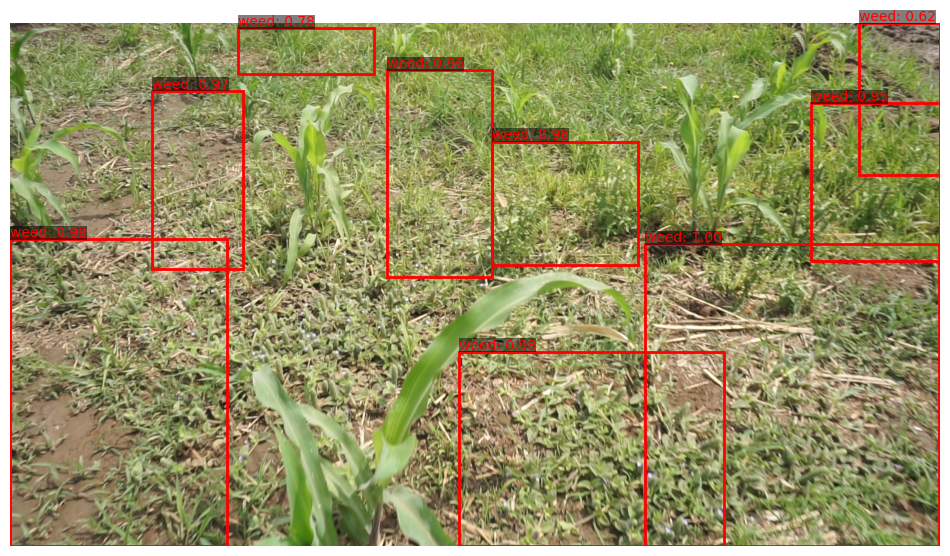


Prediction Details:
Detected Objects: 9
Breakdown:
Maize: 0
Weed: 9
Average Confidence: 0.91


In [ ]:
import matplotlib.pyplot as plt
def predict_image(image_path, model_path="faster_rcnn_fpn_best.pth", threshold=0.5, figsize=(12, 8)):
    """
    Predicts and visualizes bounding boxes for a single image using the trained model.

    Args:
        image_path (str): Path to input image
        model_path (str): Path to saved model weights
        threshold (float): Confidence threshold (0-1)
        figsize (tuple): Figure display size

    Returns:
        PIL.Image: Image with bounding boxes
        dict: Prediction data
    """
    # Load model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = get_model(num_classes=2)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    # Load image
    image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([transforms.ToTensor()])
    image_tensor = transform(image).unsqueeze(0).to(device)

    # Make prediction
    with torch.no_grad():
        prediction = model(image_tensor)[0]

    # Convert tensor to numpy arrays
    boxes = prediction['boxes'].cpu().numpy()
    scores = prediction['scores'].cpu().numpy()
    labels = prediction['labels'].cpu().numpy()

    # Filter by threshold
    mask = scores >= threshold
    filtered_boxes = boxes[mask]
    filtered_scores = scores[mask]
    filtered_labels = labels[mask]

    # Create visualization
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image)

    # Define colors and labels
    colors = {'maize': 'lime', 'weed': 'red'}
    class_names = ['maize', 'weed']

    # Draw bounding boxes
    for box, score, label in zip(filtered_boxes, filtered_scores, filtered_labels):
        x_min, y_min, x_max, y_max = box
        rect = patches.Rectangle(
            (x_min, y_min), x_max - x_min, y_max - y_min,
            linewidth=2, edgecolor=colors[class_names[label]], facecolor='none'
        )
        ax.add_patch(rect)

        # Add label text
        label_text = f"{class_names[label]}: {score:.2f}"
        ax.text(
            x_min, y_min - 5, label_text,
            color=colors[class_names[label]], fontsize=10,
            bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=0)
        )

    plt.axis('off')
    plt.show()

    # Prepare return data
    prediction_data = {
        'boxes': filtered_boxes.tolist(),
        'scores': filtered_scores.tolist(),
        'labels': [class_names[l] for l in filtered_labels.tolist()]
    }

    return image, prediction_data

# Example usage
if __name__ == "__main__":
    # Load required libraries
    import matplotlib.patches as patches

    # Test prediction
    test_image_path = "/kaggle/input/project-2/Annotated-Maize-Weed-Images/C00020602.jpg"
    original_image, predictions = predict_image(
        test_image_path,
        model_path="/kaggle/working/faster_rcnn_fpn_best.pth",
        threshold=0.6
    )

    # Print prediction data
    print("\nPrediction Details:")
    print(f"Detected Objects: {len(predictions['boxes'])}")
    print("Breakdown:")
    print(f"Maize: {predictions['labels'].count('maize')}")
    print(f"Weed: {predictions['labels'].count('weed')}")
    print(f"Average Confidence: {np.mean(predictions['scores']):.2f}")


In [ ]:
# def debug_predictions(image_path, model_path, threshold=0.1):
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#     model = get_model(num_classes=2)
#     model.load_state_dict(torch.load(model_path))
#     model.to(device)
#     model.eval()

#     image = Image.open(image_path).convert("RGB")
#     transform = transforms.Compose([transforms.ToTensor()])
#     image_tensor = transform(image).unsqueeze(0).to(device)

#     with torch.no_grad():
#         raw_prediction = model(image_tensor)[0]

#     # Print raw outputs
#     print("All Predictions (unfiltered):")
#     for box, score, label in zip(raw_prediction['boxes'], raw_prediction['scores'], raw_prediction['labels']):
#         print(f"Label: {'maize' if label == 0 else 'weed'} | Confidence: {score:.4f} | Box: {box.cpu().numpy()}")

#     # Filter and print
#     mask = raw_prediction['scores'] >= threshold
#     print(f"\nFiltered (threshold={threshold}):")
#     print(f"Maize detections: {sum(raw_prediction['labels'][mask] == 0).item()}")
#     print(f"Weed detections: {sum(raw_prediction['labels'][mask] == 1).item()}")

# # Usage
# debug_predictions(
#     "/kaggle/input/project-2/Annotated-Maize-Weed-Images/C00020602.jpg",
#     "/kaggle/working/faster_rcnn_fpn_best.pth",
#     threshold=0.5
# )


<ipython-input-5-f18d224d2ecb>:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


All Predictions (unfiltered):
Label: weed | Confidence: 0.9981 | Box: [1311.3234  456.9694 1916.4244 1080.    ]
Label: weed | Confidence: 0.9941 | Box: [   0.       445.94675  446.54437 1080.     ]
Label: weed | Confidence: 0.9840 | Box: [ 926.54846  678.1949  1473.2247  1080.     ]
Label: weed | Confidence: 0.9653 | Box: [292.20178 139.51952 481.0394  508.2409 ]
Label: weed | Confidence: 0.9584 | Box: [ 994.80914  244.48567 1296.4452   499.57794]
Label: weed | Confidence: 0.9571 | Box: [776.9649   97.2406  994.19604 523.7408 ]
Label: weed | Confidence: 0.9471 | Box: [1653.1416   165.84618 1920.       490.51532]
Label: weed | Confidence: 0.7791 | Box: [469.61667   10.009829 750.6305   105.71625 ]
Label: weed | Confidence: 0.6186 | Box: [1752.1372    0.     1919.2407  313.6763]
Label: weed | Confidence: 0.3575 | Box: [   2.019729  457.3379     90.22073  1080.      ]
Label: weed | Confidence: 0.3455 | Box: [1734.1118     33.295616 1920.        542.9516  ]
Label: weed | Confidence: 0.3231

In [ ]:
# import os
# import json
# import torch
# import torch.utils.data as data
# from torch.utils.data import DataLoader, random_split
# import torchvision
# from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
# from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
# import torchvision.transforms as transforms
# from PIL import Image, ImageDraw
# import numpy as np
# from tqdm import tqdm
# import matplotlib.pyplot as plt
# import matplotlib.patches as patches

# # Corrected Dataset Class
# class MaizeWeedDataset(data.Dataset):
#     def __init__(self, root_dir, transform=None, use_json=True):
#         self.root_dir = root_dir
#         self.transform = transform
#         self.use_json = use_json
#         self.image_files = [f for f in os.listdir(root_dir) if f.endswith('.jpg')]

#     def __len__(self):
#         return len(self.image_files)

#     def load_annotations_from_json(self, json_path, img_width, img_height):
#         with open(json_path, 'r') as f:
#             annotations = json.load(f)

#         boxes = []
#         labels = []

#         for anno in annotations[0]['annotations']:
#             x = anno['coordinates']['x']
#             y = anno['coordinates']['y']
#             width = anno['coordinates']['width']
#             height = anno['coordinates']['height']

#             x_min = max(0, x - width / 2)
#             y_min = max(0, y - height / 2)
#             x_max = min(img_width, x + width / 2)
#             y_max = min(img_height, y + height / 2)

#             boxes.append([x_min, y_min, x_max, y_max])
#             label = 1 if anno['label'] == 'maize' else 0  # Corrected label mapping
#             labels.append(label)

#         return boxes, labels

#     def load_annotations_from_txt(self, txt_path, img_width, img_height):
#         boxes = []
#         labels = []

#         with open(txt_path, 'r') as f:
#             lines = f.readlines()

#         for line in lines:
#             values = line.strip().split()
#             if len(values) >= 5:
#                 original_label = int(values[0])
#                 label = 1 - original_label  # Flip labels

#                 x_center = float(values[1]) * img_width
#                 y_center = float(values[2]) * img_height
#                 width = float(values[3]) * img_width
#                 height = float(values[4]) * img_height

#                 x_min = max(0, x_center - width / 2)
#                 y_min = max(0, y_center - height / 2)
#                 x_max = min(img_width, x_center + width / 2)
#                 y_max = min(img_height, y_center + height / 2)

#                 boxes.append([x_min, y_min, x_max, y_max])
#                 labels.append(label)

#         return boxes, labels

#     def __getitem__(self, idx):
#         img_name = self.image_files[idx]
#         img_path = os.path.join(self.root_dir, img_name)
#         img = Image.open(img_path).convert("RGB")

#         img_width, img_height = img.size

#         if self.use_json:
#             anno_path = os.path.join(self.root_dir, img_name.replace('.jpg', '.json'))
#             boxes, labels = self.load_annotations_from_json(anno_path, img_width, img_height)
#         else:
#             anno_path = os.path.join(self.root_dir, img_name.replace('.jpg', '.txt'))
#             boxes, labels = self.load_annotations_from_txt(anno_path, img_width, img_height)

#         boxes = torch.as_tensor(boxes, dtype=torch.float32)
#         labels = torch.as_tensor(labels, dtype=torch.int64)

#         target = {
#             'boxes': boxes,
#             'labels': labels,
#             'image_id': torch.tensor([idx]),
#             'area': (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]),
#             'iscrowd': torch.zeros((len(labels),), dtype=torch.int64)
#         }

#         if self.transform:
#             img = self.transform(img)

#         return img, target, img_name

# def get_model(num_classes):
#     model = fasterrcnn_resnet50_fpn_v2(weights='DEFAULT')
#     in_features = model.roi_heads.box_predictor.cls_score.in_features
#     model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

#     # Initialize bias for better class balance
#     with torch.no_grad():
#         model.roi_heads.box_predictor.cls_score.bias.data[0] = -2.0  # weed
#         model.roi_heads.box_predictor.cls_score.bias.data[1] = 1.0   # maize

#     return model

# def visualize_prediction(image, prediction, threshold=0.5):
#     draw = ImageDraw.Draw(image)
#     boxes = prediction['boxes'].cpu().numpy()
#     scores = prediction['scores'].cpu().numpy()
#     labels = prediction['labels'].cpu().numpy()

#     colors = ['red', 'green']  # weed: red, maize: green
#     class_names = ['weed', 'maize']

#     for box, score, label in zip(boxes, scores, labels):
#         if score >= threshold:
#             box = box.astype(int)
#             draw.rectangle([(box[0], box[1]), (box[2], box[3])],
#                          outline=colors[label], width=3)
#             draw.text((box[0], box[1]-10),
#                     f"{class_names[label]}: {score:.2f}",
#                     fill=colors[label])
#     return image

# def train_model(model, train_loader, val_loader, optimizer, scheduler, num_epochs=15):
#     device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
#     model.to(device)

#     best_val_loss = float('inf')
#     history = {
#         'train_loss': [],
#         'val_loss': [],
#         'lr': []
#     }

#     for epoch in range(num_epochs):
#         print(f'Epoch {epoch+1}/{num_epochs}')

#         # Training phase
#         model.train()
#         train_loss = 0.0

#         for images, targets, _ in tqdm(train_loader, desc="Training"):
#             images = [img.to(device) for img in images]
#             targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

#             optimizer.zero_grad()

#             loss_dict = model(images, targets)
#             losses = sum(loss for loss in loss_dict.values())

#             losses.backward()
#             optimizer.step()

#             train_loss += losses.item()

#         # Validation phase - Critical Fix: Use torch.no_grad() but keep model.train()
#         val_loss = 0.0
#         with torch.no_grad():
#             model.train()  # Keep in train mode for loss computation
#             for images, targets, _ in tqdm(val_loader, desc="Validating"):
#                 images = [img.to(device) for img in images]
#                 targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

#                 loss_dict = model(images, targets)
#                 val_loss += sum(loss for loss in loss_dict.values()).item()

#         # Learning rate scheduling
#         if scheduler is not None:
#             scheduler.step()

#         # Calculate epoch metrics
#         avg_train_loss = train_loss / len(train_loader)
#         avg_val_loss = val_loss / len(val_loader)
#         current_lr = optimizer.param_groups[0]['lr']

#         history['train_loss'].append(avg_train_loss)
#         history['val_loss'].append(avg_val_loss)
#         history['lr'].append(current_lr)

#         print(f'Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6f}')

#         # Save best model
#         if avg_val_loss < best_val_loss:
#             best_val_loss = avg_val_loss
#             torch.save(model.state_dict(), 'best_model.pth')
#             print(f'New best model saved with val loss: {best_val_loss:.4f}')

#     return model, history


# def main():
#     data_dir = "/kaggle/input/project-2/Annotated-Maize-Weed-Images"
#     output_dir = "/kaggle/working/results"
#     os.makedirs(output_dir, exist_ok=True)

#     transform = transforms.Compose([
#         transforms.ToTensor(),
#         transforms.RandomHorizontalFlip(p=0.5),
#         transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)
#     ])

#     dataset = MaizeWeedDataset(data_dir, transform=transform, use_json=True)
#     train_size = int(0.7 * len(dataset))
#     val_size = int(0.15 * len(dataset))
#     test_size = len(dataset) - train_size - val_size

#     train_dataset, val_dataset, test_dataset = random_split(
#         dataset, [train_size, val_size, test_size],
#         generator=torch.Generator().manual_seed(42)
#     )

#     train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
#     val_loader = DataLoader(val_dataset, batch_size=4, collate_fn=lambda x: tuple(zip(*x)))
#     test_loader = DataLoader(test_dataset, batch_size=1, collate_fn=lambda x: tuple(zip(*x)))

#     model = get_model(num_classes=2)
#     optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
#     scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2)

#     print("Starting training...")
#     model = train_model(model, train_loader, val_loader, optimizer, scheduler)

#     print("\nEvaluating on test set...")
#     model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))
#     model.eval()

#     for images, _, img_names in test_loader:
#         image = images[0].to("cuda" if torch.cuda.is_available() else "cpu")
#         with torch.no_grad():
#             prediction = model([image])[0]

#         original_image = transforms.ToPILImage()(images[0].cpu())
#         result_image = visualize_prediction(original_image, prediction)
#         result_image.save(os.path.join(output_dir, f"pred_{img_names[0]}"))

# if __name__ == "__main__":
#     main()


Starting training...
Epoch 1/15


Validating: 100%|██████████| 19/19 [00:13<00:00,  1.36it/s]


TypeError: ReduceLROnPlateau.step() missing 1 required positional argument: 'metrics'